# Setup
- Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
- Install TerraTorch
    - You will have to restart the session after installing terratorch (it kinda looks like an error)

In [1]:
!pip install terratorch==1.1.1
!pip install gdown tensorboard zarr earthaccess folium

In [189]:
import logging
from datetime import datetime, timedelta
from pathlib import Path

import earthaccess
import folium
import gdown
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import rasterio
import terratorch
from rasterio.features import rasterize
from rasterio.plot import show
from rasterio.transform import from_origin
from shapely import wkt
from shapely.geometry import polygon
from torch.utils.data import DataLoader
from torchgeo.datasets import RasterDataset, stack_samples, unbind_samples, utils
from torchgeo.samplers import RandomGeoSampler
import torch
from lightning import LightningDataModule
from torch.utils.data import DataLoader
from torchgeo.datasets import RasterDataset, BoundingBox
from torchgeo.datasets.utils import stack_samples
from torchgeo.samplers import RandomGeoSampler, GridGeoSampler
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import albumentations as A
from albumentations.pytorch import ToTensorV2

from IPython.core.debugger import set_trace

logging.getLogger().setLevel(logging.WARNING)

# Download the HWDS dataset

In [142]:
hwds_google_drive_id = '1TC7JsbrSGTpS0CEvEbGp9TqtxDjAdLBG'
drive_url = f'https://drive.google.com/uc?id={hwds_google_drive_id}'
filename = '25_hwds_shapefile'

if not Path(f'{filename}.zip').exists():
  gdown.download(drive_url)
  !unzip 25_hwds_shapefile.zip

shp_path = Path(filename) / 'hls_hwds_polygons.shp'

# Load the data using geopandas

In [143]:
gdf = gpd.read_file(shp_path)

2019-05-17


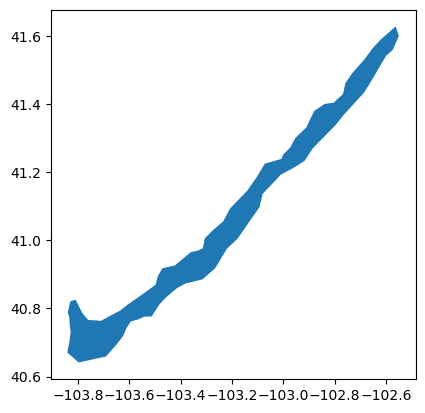

In [144]:
swath_id = '97'
swath_gdf = gdf[gdf['swathID'] == swath_id]
swath = swath_gdf.iloc[0]

best_post_date = datetime(year=2019, month=5, day=24) # Update this for different swaths

swath_gdf.plot()
print(swath['swathDate'])

# Find hls data based on polygon

In [145]:
earthaccess.login()

In [146]:
geometry = polygon.orient(swath.geometry, sign=1.0)

results = earthaccess.search_data(
    short_name='HLSS30',
    polygon=list(geometry.exterior.coords),
    temporal=(best_post_date, best_post_date + timedelta(days=1))
)

In [147]:
geotiff_list = results

def plot_geotiff_extents(results_list, selected_gdf):
    all_lats, all_lons = [], []
    
    m = folium.Map(tiles="OpenStreetMap")
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, metadata in enumerate(results_list):
        points = metadata['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
        
        footprint_coords = []
        for point in points:
            lat, lon = point['Latitude'], point['Longitude']
            footprint_coords.append((lat, lon))
            all_lats.append(lat)
            all_lons.append(lon)
        
        tile_color = colors[i % len(colors)]

        folium.Polygon(
            locations=footprint_coords,
            tooltip=f"HLS Tile: {metadata['umm']['GranuleUR']}",
            color=tile_color,
            weight=3,
            fill=True,
            fill_color=tile_color,
            fill_opacity=0.3
        ).add_to(m)
        
    folium.GeoJson(
        selected_gdf.to_json(),
        style_function=lambda x: {
            'fillColor': '#8c564b', 
            'color': '#8c564b',
            'weight': 4,
            'fillOpacity': 0.5
        },
        tooltip=folium.features.GeoJsonTooltip(fields=['swathID', 'swathDate'], aliases=['Swath ID:', 'Date:'], localize=True)
    ).add_to(m)
    
    if all_lats and all_lons:
        map_bounds = [[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]]
        m.fit_bounds(map_bounds)

    folium.LayerControl().add_to(m)
    
    return m

In [148]:
final_map = plot_geotiff_extents(results, swath_gdf)
final_map

In [149]:
data_path = Path.cwd() / 'data' / f'swath_{swath_id}'
hls_path = data_path / 'HLS'
label_path = data_path / 'LABEL'

for data_path in (hls_path, label_path):
    data_path.mkdir(parents=True, exist_ok=True) 

In [150]:
files = earthaccess.download(
    results,
    local_path=hls_path  # Specify where to save files
)

QUEUEING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/126 [00:00<?, ?it/s]

## Turn label geometry into raster

In [151]:
utm_crs = gdf.estimate_utm_crs()
gdf_crs = gdf.to_crs(utm_crs)

swath_crs_gdf = gdf_crs[gdf_crs['swathID'] == swath_id]

In [152]:
def rasterize_swath(selected_swath_gdf):
    pixel_size_meters = 30
    padding_meters = 1000

    selected = selected_swath_gdf.iloc[0]
    geom = selected.geometry
    minx, miny, maxx, maxy = geom.bounds
    minx -= padding_meters
    miny -= padding_meters
    maxx += padding_meters
    maxy += padding_meters

    width = int(np.ceil((maxx - minx) / pixel_size_meters))
    height = int(np.ceil((maxy - miny) / pixel_size_meters))

    transform = from_origin(minx, maxy, pixel_size_meters, pixel_size_meters)

    rasterized = rasterize(
        [(geom, 1)],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    out_path = label_path / f'swathID_{swath_id}.tif'

    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='uint8',
        crs=selected_swath_gdf.crs,
        transform=transform
    ) as dst:
        dst.write(rasterized, 1)
        dst.update_tags(polygon_id=str(swath_id))
    
    return out_path

label_raster = rasterize_swath(swath_crs_gdf)

## Visualize Label Raster

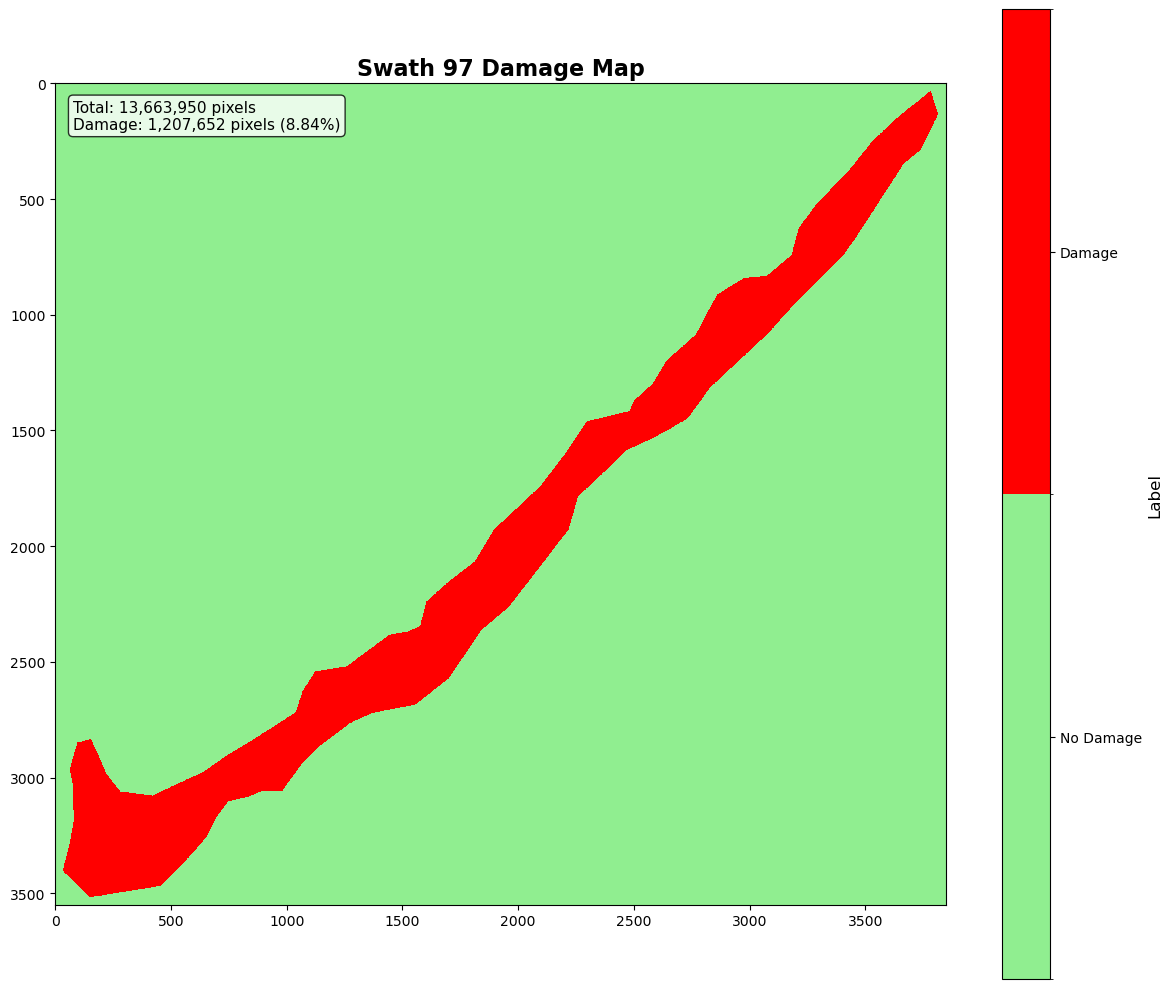

In [153]:
with rasterio.open(label_raster) as src:
    data = src.read(1)
    
    colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
    cmap = mcolors.ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(f'Swath {swath_id} Damage Map', fontsize=16, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_label('Label', fontsize=12)
    cbar.ax.set_yticklabels(['No Damage', 'Damage'])
    
    total_pixels = data.size
    damage_pixels = np.sum(data == 1)
    damage_pct = (damage_pixels / total_pixels) * 100
    
    textstr = f'Total: {total_pixels:,} pixels\nDamage: {damage_pixels:,} pixels ({damage_pct:.2f}%)'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

## Setup DataModule 

In [184]:
class HLSDataset(RasterDataset):
    """
    HLS dataset using TorchGeo's RasterDataset base class.
    
    Example file name:
        HLS.S30.T13TFF.2019144T173909.v2.0.B08.tif

    Bands:
        B01 ->  COASTAL
        B02 ->  BLUE
        B03 ->  GREEN
        B04 ->  RED
        B05 ->  REDEDGE1
        B06 ->  REDEDGE2
        B07 ->  REDEDGE3
        B08 ->  NIR
        B8A ->  NIR08
        B09 ->  NIR09
        B11 ->  SWIR16
        B12 ->  SWIR22
    """
    
    filename_glob = "HLS.*.tif"
    filename_regex = r"^HLS\.(?P<sensor>[SL])30\.(?P<tile>T\w+)\.(?P<date>\d+T\d+)\.v\d+\.\d+\.(?P<band>B\w+|SZA|SAA|VZA|VAA)\.tif$"
    date_format = '%Y%d%mT%H%M%S'
    
    separate_files = True
    is_image = True
    
    all_bands = ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B10", "B11", "B12", "Fmask")
    rgb_bands = ('B04', 'B03', 'B02')
    
    def plot(self, sample):
        rgb_indices = []
        for band in self.rgb_bands:
            rgb_indices.append(self.all_bands.index(band))
        
        image = sample['image'][rgb_indices].permute(1, 2, 0)
        image = torch.clamp(image / 10000, min=0, max=1).numpy()
        
        fig, ax = plt.subplots()
        ax.imshow(image)
        ax.axis('off')
        
        return fig

class LabelDataset(RasterDataset):
    filename_glob = "swathID_*.tif"
    is_image = False

    def plot(self, sample):
        mask = sample['mask']
        
        if mask.dim() == 3:  # (C, H, W)
            mask = mask[0]
        elif mask.dim() == 4:  # (B, C, H, W)
            mask = mask[0, 0]
        
        mask = mask.numpy()
        
        fig, ax = plt.subplots()
        ax.imshow(mask, cmap='viridis')
        ax.axis('off')
        
        return fig


In [200]:

def terramind_collate(batch):
    stacked = stack_samples(batch)
    return {
        'image': {
            'S2L2A': stacked['image']
        },
        'mask': stacked['mask']
    }
    
def calc_statistics(dataset, num_samples=10, patch_size=256, batch_size=8):
    """
    Calculates the per-channel mean and std for a TorchGeo RasterDataset.
    """
    # 1. Use a GeoSampler to sample random patches across the geographic extent
    sampler = RandomGeoSampler(dataset, size=patch_size, length=num_samples)
    
    # 2. Setup DataLoader with the stack_samples collate function
    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        sampler=sampler, 
        collate_fn=stack_samples
    )

    # 3. Running sum and squared sum for numerical stability
    channels = len(dataset.bands)
    sum_ = torch.zeros(channels)
    sum_sq = torch.zeros(channels)
    total_pixels = 0

    for batch in loader:
        images = batch['image'].float()  # (B, C, H, W)
        
        pixels_per_batch = images.size(0) * images.size(2) * images.size(3)
        total_pixels += pixels_per_batch
        
        sum_ += images.sum(dim=(0, 2, 3))
        sum_sq += (images**2).sum(dim=(0, 2, 3))

    mean = sum_ / total_pixels
    var = (sum_sq / total_pixels) - (mean**2)
    std = torch.sqrt(var)

    return mean, std
    
class HLSDataModule(NonGeoDataModule):  
    def __init__(
        self,
        hls_path: str,
        label_path: str,
        batch_size: int = 8,
        patch_size: int = 224,
        train_length: int = 100,
        val_length: int = 20,
        num_workers: int = 4,
    ):
        super().__init__()
        self.hls_path = hls_path
        self.label_path = label_path
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.train_length = train_length
        self.val_length = val_length
        self.num_workers = num_workers
        
    def setup(self, stage=None):
        # Initialize datasets
        self.hls_dataset = HLSDataset(
            paths=self.hls_path,
            bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
                   'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
        )
        
        mean, std = calc_statistics(self.hls_dataset)

        transform = A.Compose([
            A.Normalize(mean=mean.tolist(), std=std.tolist(), max_pixel_value=1.0),  # set max_pixel_value=1.0 if already scaled
            ToTensorV2()
        ])
        self.hls_dataset.transforms = transform
        
        self.label_dataset = LabelDataset(paths=self.label_path)
        self.dataset = self.label_dataset & self.hls_dataset
        bounds = self.dataset.bounds
        
        
        split_x = bounds.minx + 0.8 * (bounds.maxx - bounds.minx)
        
        # Define train/val ROIs
        self.train_roi = BoundingBox(
            minx=bounds.minx,
            maxx=split_x,
            miny=bounds.miny,
            maxy=bounds.maxy,
            mint=bounds.mint,
            maxt=bounds.maxt,
        )
        self.val_roi = BoundingBox(
            minx=split_x,
            maxx=bounds.maxx,
            miny=bounds.miny,
            maxy=bounds.maxy,
            mint=bounds.mint,
            maxt=bounds.maxt,
        )

        
        # Train/val samplers using GridGeoSampler
        self.train_sampler = GridGeoSampler(
            self.dataset,
            size=self.patch_size,
            stride=self.patch_size,
            roi=self.train_roi,
        )
        self.val_sampler = GridGeoSampler(
            self.dataset,
            size=self.patch_size,
            stride=self.patch_size,
            roi=self.val_roi,
        )

        if stage in ['fit', 'validate']:
            self.train_dataset = self.train_dataloader()
            self.val_dataset = self.val_dataloader()

    def train_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.train_sampler,
            batch_size=self.batch_size,
            collate_fn=terramind_collate,
            num_workers=self.num_workers
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.val_sampler,
            batch_size=self.batch_size,
            collate_fn=terramind_collate,
            num_workers=self.num_workers
        )
        
    def plot(self, sample, split='val'):
        def plot_binary_mask(ax, mask_data, title, fig):
            if mask_data.dim() == 3:  # (C, H, W)
                mask_data = mask_data[0]
            elif mask_data.dim() == 4:  # (B, C, H, W)
                mask_data = mask_data[0, 0]
                
            mask_np = mask_data.numpy()
            
            # Create colormap and norm
            colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
            cmap = ListedColormap(colors)
            bounds = [-0.5, 0.5, 1.5]
            norm = BoundaryNorm(bounds, cmap.N)
            
            # Plot mask
            im = ax.imshow(mask_np, cmap=cmap, norm=norm, interpolation='nearest')
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.axis('off')
            
            # Add colorbar
            cbar = fig.colorbar(im, ax=ax, ticks=[0, 1], fraction=0.046)
            cbar.set_label(title, fontsize=12)
            cbar.ax.set_yticklabels(['No Damage', 'Damage'])
            
            # Add statistics
            total_pixels = mask_np.size
            damage_pixels = np.sum(mask_np == 1)
            damage_pct = (damage_pixels / total_pixels) * 100
            
            textstr = f'Total: {total_pixels:,} pixels\nDamage: {damage_pixels:,} ({damage_pct:.2f}%)'
            props = dict(boxstyle='round', facecolor='white', alpha=0.8)
            ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
                    fontsize=10, verticalalignment='top', bbox=props)
        
        # Main plotting logic
        if 'image' in sample and isinstance(sample['image'], dict):
            standard_sample = {
                'image': sample['image']['S2L2A'],
                'mask': sample['mask']
            }
        else:
            standard_sample = sample
        
        # Determine number of subplots based on presence of prediction
        has_prediction = 'prediction' in sample
        num_plots = 3 if has_prediction else 2
        
        fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
        
        # Plot HLS RGB Image
        hls_fig = self.hls_dataset.plot(standard_sample)
        hls_ax = hls_fig.axes[0]
        for image in hls_ax.get_images():
            axes[0].imshow(image.get_array())
        axes[0].set_title('HLS RGB Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        plt.close(hls_fig)
        
        # Plot Label Mask
        plot_binary_mask(axes[1], standard_sample['mask'], 'Label', fig)
        
        # Plot Prediction if present
        if has_prediction:
            plot_binary_mask(axes[2], sample['prediction'], 'Prediction', fig)
        
        plt.tight_layout()
        return fig

In [201]:
datamodule = HLSDataModule(
    hls_path=hls_path,
    label_path=label_path,
    batch_size=8
)

datamodule.setup()

Converting HLSDataset CRS from EPSG:32613 to EPSG:32614


In [198]:
dataloader = datamodule.train_dataloader()

In [199]:
batch = next(iter(dataloader))

sample = {
    'image': {'S2L2A': batch['image']['S2L2A'][0]},
    'mask': batch['mask'][0]
}
fig = datamodule.plot(sample)
plt.show()

RasterioError: Caught RasterioError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torchgeo/datasets/geo.py", line 1042, in __getitem__
    samples = [ds[query] for ds in se

In [158]:
MODALITIES = ['S2L2A']

model = terratorch.tasks.SemanticSegmentationTask(
  model_factory='EncoderDecoderFactory',
  model_args={
      'backbone': 'terramind_v1_base',
      'backbone_pretrained': True,
      'backbone_modalities': MODALITIES,
      'necks': [
          {'name': 'SelectIndices', 'indices': [2, 5, 8, 11]},
          {'name': 'ReshapeTokensToImage', 'remove_cls_token': False},
          {'name': 'LearnedInterpolateToPyramidal'}
      ],
      'decoder': 'UNetDecoder',
      'decoder_channels': [512, 256, 128, 64],
      'head_dropout': 0.1,
      'num_classes': 2,
  },
  loss='dice',
  optimizer='AdamW',
  lr=1e-5,
  ignore_index=-1,
  freeze_backbone=False,
  freeze_decoder=False,
  plot_on_val=True,
  class_names=['no-damage', 'damage'],
)

In [159]:

# TensorBoard logger
tb_logger = TensorBoardLogger(
  save_dir='output/terramind_base_hwds/',
  name='tensorboard_logs',
)

# Callbacks
checkpoint_callback = pl.callbacks.ModelCheckpoint(
  dirpath='output/terramind_base_hwds/checkpoints/',
  filename='best-epoch{epoch:02d}-mIoU{val/mIoU:.4f}',
  monitor='val/mIoU',
  mode='max',
  save_top_k=1,
  save_last=True,
  save_weights_only=False,
  auto_insert_metric_name=False,
)

lr_monitor = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
  accelerator='auto',
  strategy='auto',
  num_nodes=1,
  logger=tb_logger,
  max_epochs=3,
  log_every_n_steps=5,
  callbacks=[
      checkpoint_callback,
      lr_monitor,
      pl.callbacks.RichProgressBar()
  ],
  default_root_dir='output/terramind_base_hwds/',
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [160]:
%load_ext tensorboard
%tensorboard --logdir output

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1117368), started 4:05:08 ago. (Use '!kill 1117368' to kill it.)

In [161]:
trainer.fit(model, datamodule=datamodule)

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/wbhorn/repositories/tools/terramind-docs/severe-weather/torchgeo/output/terramind_base_hwds/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Converting HLSDataset CRS from EPSG:32613 to EPSG:32614


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  102 M │ train │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │
└───┴───────────────┴──────────────────┴────────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 87.3 M                                                                                       
Total params: 102 M                                                                                                
Total estimated model params size (MB): 411                                                                        
Modules in train mode: 288                                                                                         
Modules in eval mode: 0

Output()

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

/home/wbhorn/miniforge3/envs/torchgeo/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: 
UserWarning: The ``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may 
lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined